# Chapter 11 — Intelligent Measurement and the AI Transition
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 11 — Intelligent Measurement and the AI Transition.

The fundamental problem of modern strain measurement is not sensitivity — it is volume. A single modern test setup with 512 channels sampled at 10 kHz for a week generates roughly 12 terabytes (about 12,000 GB) of raw data. A human analyst reviewing that data at a realistic pace — approximately 100 MB per working day — would need more than three centuries to read it all. This is the *analyst bottleneck*: the gap between the rate at which data can be collected and the rate at which it can be understood.

Machine learning does not eliminate the engineer. It restores the ability to listen — to find the signals buried in a dataset that no individual could audit by hand. The figures below make that argument numerically. The left panel shows data volume by era on a logarithmic scale; the right converts that volume into analyst-days, making the bottleneck visceral.

**This notebook demonstrates:**
1. Data volume growth across six decades of strain measurement practice (log scale)
2. Analyst-days required to review each era's data — the case for automated analysis

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Figure output directory — must match the path the book \includegraphics
OUT_DIR = Path("../src/media/ch11")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — The Data Volume Problem and the Analyst Bottleneck

The numbers below are estimates, not records, but they are conservative ones. Real modern test programs often exceed these figures — a road load data acquisition campaign on a vehicle fleet can run for months across hundreds of channels. The key variable is not any single parameter but their product: channels × sample rate × duration × bytes per sample. Each factor has grown by orders of magnitude since the 1960s, and their product has grown by many more.

The right panel translates the raw gigabytes into a human metric: analyst-days. This is the number of working days a single analyst would need, reviewing data continuously at a rate of 100 MB/day, to read the entire dataset from each era. The transition from "manageable" to "impossible" happens somewhere in the 1990s. This is not a story about engineers becoming lazy — it is a story about the data outrunning any humanly sustainable review process. Automated analysis is not a luxury; it is the only way to extract meaning from data at this scale.

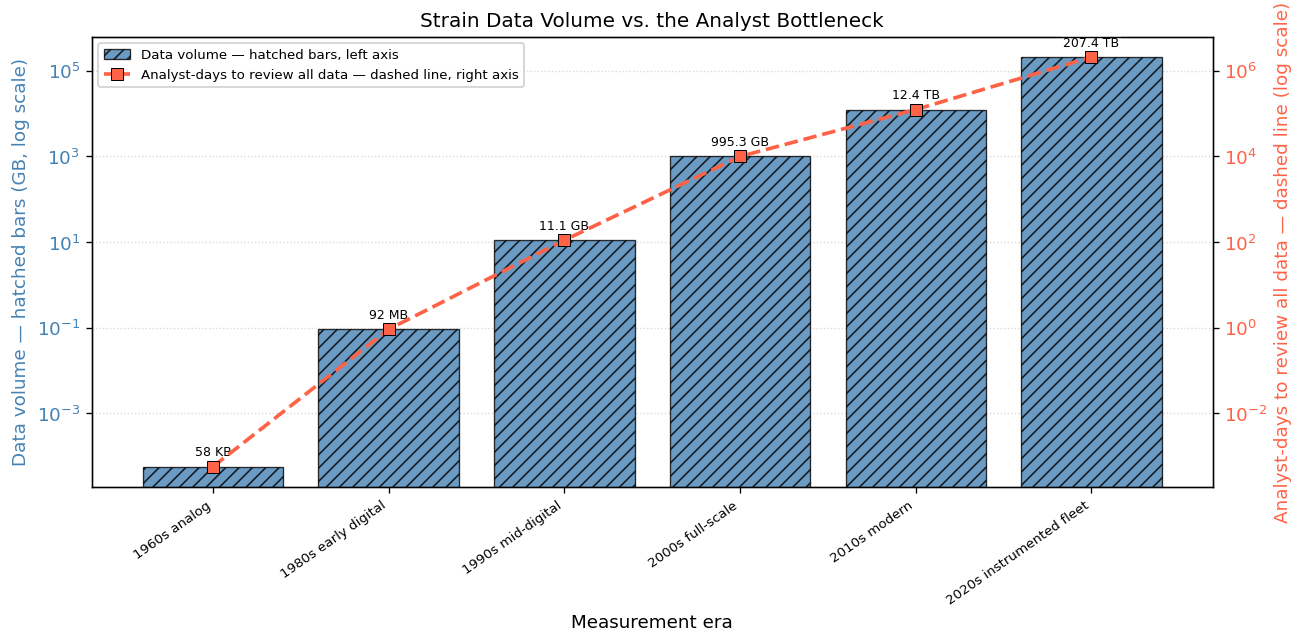

The case for ML: not replacing the engineer, but restoring the ability to listen to the data.


In [2]:
# --- Assumptions, named so they are easy to challenge ---------------------
BYTES_PER_GB = 1e9                    # decimal gigabyte (bytes)
ANALYST_REVIEW_RATE_GB_PER_DAY = 0.1  # ~100 MB a single analyst can meaningfully review per day
SECONDS_PER_HOUR = 3600


def dataset_size_gb(channels, sample_rate_hz, duration_s, bytes_per_sample):
    """Raw size (in GB) of a synchronous multi-channel recording.

    size = channels * sample_rate * duration * bytes_per_sample, converted to GB.
    """
    total_bytes = channels * sample_rate_hz * duration_s * bytes_per_sample
    return total_bytes / BYTES_PER_GB


def analyst_days(size_gb, review_rate_gb_per_day=ANALYST_REVIEW_RATE_GB_PER_DAY):
    """Working days one analyst needs to review `size_gb` at a fixed review rate."""
    return size_gb / review_rate_gb_per_day


def format_size(size_gb):
    """Human-readable KB/MB/GB/TB label for a value expressed in gigabytes."""
    if size_gb >= 1_000:
        return f'{size_gb / 1_000:.1f} TB'
    if size_gb >= 1:
        return f'{size_gb:.1f} GB'
    if size_gb >= 1e-3:
        return f'{size_gb * 1e3:.0f} MB'
    return f'{size_gb * 1e6:.0f} KB'


# Era label, channels, sample rate (Hz), test duration (s), bytes per sample.
# Durations are written as <hours> * SECONDS_PER_HOUR for readability.
configs = [
    ("1960s analog (1 channel)",             1,     1,     8 * SECONDS_PER_HOUR,   2),
    ("1980s early digital (16 ch)",          16,    100,   8 * SECONDS_PER_HOUR,   2),
    ("1990s mid-digital (64 ch)",            64,    1000,  24 * SECONDS_PER_HOUR,  2),
    ("2000s full-scale (256 ch)",            256,   5000,  72 * SECONDS_PER_HOUR,  3),
    ("2010s modern (512 ch)",                512,   10000, 168 * SECONDS_PER_HOUR, 4),
    ("2020s instrumented fleet (2000 ch)",   2000,  10000, 720 * SECONDS_PER_HOUR, 4),
]

labels = [c[0] for c in configs]
short_labels = [label.split('(')[0].strip() for label in labels]
data_GB = [dataset_size_gb(ch, rate, dur, bp) for _, ch, rate, dur, bp in configs]
review_days = [analyst_days(d) for d in data_GB]

# One graphic, two Y-axes: data volume (bars, left) and the human review
# burden it implies (line, right). Both on log scales and sharing the era axis.
# The bars are hatched and the line is dashed with square markers, so the two
# series stay apart in the black-and-white softcover edition; each axis label
# names its own mark.
fig, ax1 = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(labels))

# --- Left axis: raw data volume by era (log scale) ---
bars = ax1.bar(x, data_GB, color='steelblue', alpha=0.8, zorder=2,
               hatch='///', edgecolor='black', linewidth=0.8)
ax1.set_yscale('log')
ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
ax1.set_xlabel('Measurement era')
ax1.set_ylabel('Data volume — hatched bars (GB, log scale)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, axis='y', linestyle=':', alpha=0.5)
for bar, val in zip(bars, data_GB):
    ax1.text(bar.get_x() + bar.get_width() / 2, val * 1.8,
             format_size(val), ha='center', fontsize=7.5, zorder=4,
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.6))

# --- Right axis: analyst-days to review every byte (log scale) ---
ax2 = ax1.twinx()
ax2.set_yscale('log')
line, = ax2.plot(x, review_days, color='tomato', marker='s', markersize=7,
                 markeredgecolor='black', markeredgewidth=0.6,
                 linestyle='--', lw=2.2, zorder=3)
ax2.set_ylabel('Analyst-days to review all data — dashed line (log scale)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_title('Strain Data Volume vs. the Analyst Bottleneck')
ax1.legend([bars, line],
           ['Data volume — hatched bars, left axis',
            'Analyst-days to review all data — dashed line, right axis'],
           loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig11_nb1_data_volume_growth.png', bbox_inches='tight', dpi=300)
plt.show()

print("The case for ML: not replacing the engineer, but restoring the ability to listen to the data.")

---
## Where to take this next

This notebook makes a single argument with two bars. A few concrete ways to build on it:

- **Swap the estimates for a real archive.** The `configs` here are illustrative. Point `dataset_size_gb` at an actual test campaign — walk a directory of acquisition files with `pathlib`, sum their true sizes, and plot the growth curve for your own lab instead.
- **Model the analyst rate honestly.** The flat `ANALYST_REVIEW_RATE_GB_PER_DAY = 0.1` is deliberately crude. Make it depend on channel count and signal complexity, then overlay a second "machine-assisted" curve showing how automated triage raises effective throughput — the quantitative case for the methods in Part IX.
- **Add a storage-cost axis.** Multiply each era's volume by a representative $/GB storage cost for that decade and plot it alongside. The same data, reframed in dollars, shows why *falling storage cost* — not just rising channel counts — is what made continuous high-density recording practical.